# Étape 2 - Identification des structures thématiques

**Corpus :** Professions de foi - législatives 1993  
**Objectif :** Estimer la structure thématique latente du corpus via LDA et BERTopic, sélectionner le nombre de topics par cohérence, interpréter qualitativement les topics, puis calculer les indicateurs de spécialisation partisane.

**Deux approches complémentaires (cf. cours, slides LDA vs NMF) :**  
- **LDA (Gensim)** - modèle génératif probabiliste, bag-of-words, topics diffus mais bien fondés statistiquement  
- **BERTopic** - représentations contextuelles (SentenceTransformer multilingue), clusters denses, topics plus « nets »

---

## 0. Imports et chargement du corpus préparé

In [1]:
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from pathlib import Path

# Gensim - LDA
from gensim import corpora
from gensim.models import LdaModel, CoherenceModel

# Sklearn - CountVectorizer pour BERTopic
from sklearn.feature_extraction.text import CountVectorizer

# BERTopic
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN
from sentence_transformers import SentenceTransformer

# Viz interactive
import pyLDAvis
import pyLDAvis.gensim_models

PROCESSED_DIR = Path("../data/processed")
FIGURES_DIR   = Path("../figures")
FIGURES_DIR.mkdir(exist_ok=True)

# --- Chargement du corpus (produit à l'étape 1) ---
df = pd.read_csv(PROCESSED_DIR / "corpus_1993.csv")
print(f"Corpus chargé : {len(df)} documents")

# Tokens (JSONL)
tokens_list, ids_list = [], []
with open(PROCESSED_DIR / "tokens_1993.jsonl") as f:
    for line in f:
        row = json.loads(line)
        ids_list.append(row["id"])
        tokens_list.append(row["tokens"])

# Aligner l'ordre tokens ↔ df
tok_df = pd.DataFrame({"id": ids_list, "tokens": tokens_list})
df = df.merge(tok_df, on="id", how="inner")
print(f"Après fusion tokens : {len(df)} documents")

Corpus chargé : 5835 documents
Après fusion tokens : 5835 documents


---
## PARTIE A - LDA (Gensim)

### A.1 Construction du dictionnaire et du corpus BoW

On filtre les mots très rares (< 10 docs) et très fréquents (> 60 % des docs) - cette étape est importante pour la qualité du LDA (cf. cours p.14).

In [2]:
processed_texts = df["tokens"].tolist()

# Dictionnaire Gensim
dictionary = corpora.Dictionary(processed_texts)
print(f"Vocabulaire avant filtrage : {len(dictionary)} termes")

dictionary.filter_extremes(
    no_below=10,    # apparaît dans au moins 10 docs
    no_above=0.60,  # dans moins de 60 % des docs
    keep_n=20_000   # garde les 20 000 plus fréquents
)
print(f"Vocabulaire après filtrage : {len(dictionary)} termes")

# Corpus BoW
corpus_bow = [dictionary.doc2bow(tokens) for tokens in processed_texts]
print(f"Corpus BoW prêt : {len(corpus_bow)} documents")

Vocabulaire avant filtrage : 50452 termes
Vocabulaire après filtrage : 7473 termes
Corpus BoW prêt : 5835 documents


### A.2 Sélection du nombre de topics par cohérence Cv

Le prof insiste (cours p.18-20) : **ne pas choisir le nombre de topics à l'œil**. On utilise la **cohérence Cv** (meilleure corrélation avec les évaluations humaines, Röder et al. 2015) sur une grille de valeurs. On calcule aussi la **perplexité** à titre indicatif (mais elle ne remplace pas la cohérence).

> ⚠️ Cette cellule peut prendre ~10-20 min selon la machine (CPU). Sur GPU ou avec `workers` > 1, c'est plus rapide.

In [3]:
K_RANGE = [5, 7, 10, 12, 15]
PASSES  = 15

coherence_scores = []
perplexity_scores = []

for k in K_RANGE:
    print(f"  Entraînement LDA avec k={k}...", end=" ")
    lda = LdaModel(
        corpus=corpus_bow,
        id2word=dictionary,
        num_topics=k,
        passes=PASSES,
        alpha="auto",
        eta="auto",
        random_state=42,
        eval_every=None
    )
    # Cohérence Cv
    cm_cv = CoherenceModel(
        model=lda,
        texts=processed_texts,
        dictionary=dictionary,
        coherence="c_v"
    )
    coh = cm_cv.get_coherence()
    # Perplexité (log-vraisemblance)
    perp = lda.log_perplexity(corpus_bow)
    coherence_scores.append(coh)
    perplexity_scores.append(perp)
    print(f"Cv={coh:.4f}, perplexité={perp:.2f}")

# Choisir le k optimal = pic de cohérence Cv
best_idx = int(np.argmax(coherence_scores))
K_OPTIMAL = K_RANGE[best_idx]
print(f"\n→ k optimal retenu : {K_OPTIMAL} (Cv = {coherence_scores[best_idx]:.4f})")

  Entraînement LDA avec k=5... 

/opt/python/lib/python3.13/multiprocessing/popen_fork.py:67: DeprecationWarning: This process (pid=11722) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/opt/python/lib/python3.13/multiprocessing/popen_fork.py:67: DeprecationWarning: This process (pid=11722) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/opt/python/lib/python3.13/multiprocessing/popen_fork.py:67: DeprecationWarning: This process (pid=11722) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/opt/python/lib/python3.13/multiprocessing/popen_fork.py:67: DeprecationWarning: This process (pid=11722) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/opt/python/lib/python3.13/multiprocessing/popen_fork.py:67: DeprecationWarning: This process (pid=11722) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/opt/pytho

Cv=0.6044, perplexité=-7.16
  Entraînement LDA avec k=7... 

/opt/python/lib/python3.13/multiprocessing/popen_fork.py:67: DeprecationWarning: This process (pid=11722) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/opt/python/lib/python3.13/multiprocessing/popen_fork.py:67: DeprecationWarning: This process (pid=11722) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/opt/python/lib/python3.13/multiprocessing/popen_fork.py:67: DeprecationWarning: This process (pid=11722) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/opt/python/lib/python3.13/multiprocessing/popen_fork.py:67: DeprecationWarning: This process (pid=11722) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/opt/python/lib/python3.13/multiprocessing/popen_fork.py:67: DeprecationWarning: This process (pid=11722) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/opt/pytho

Cv=0.6324, perplexité=-7.06
  Entraînement LDA avec k=10... 

...

Cv=0.5799, perplexité=-6.99
  Entraînement LDA avec k=12... 

/opt/python/lib/python3.13/multiprocessing/popen_fork.py:67: DeprecationWarning: This process (pid=11722) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/opt/python/lib/python3.13/multiprocessing/popen_fork.py:67: DeprecationWarning: This process (pid=11722) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/opt/python/lib/python3.13/multiprocessing/popen_fork.py:67: DeprecationWarning: This process (pid=11722) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/opt/python/lib/python3.13/multiprocessing/popen_fork.py:67: DeprecationWarning: This process (pid=11722) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/opt/python/lib/python3.13/multiprocessing/popen_fork.py:67: DeprecationWarning: This process (pid=11722) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/opt/pytho

Cv=0.5663, perplexité=-7.08
  Entraînement LDA avec k=15... 

/opt/python/lib/python3.13/multiprocessing/popen_fork.py:67: DeprecationWarning: This process (pid=11722) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/opt/python/lib/python3.13/multiprocessing/popen_fork.py:67: DeprecationWarning: This process (pid=11722) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/opt/python/lib/python3.13/multiprocessing/popen_fork.py:67: DeprecationWarning: This process (pid=11722) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/opt/python/lib/python3.13/multiprocessing/popen_fork.py:67: DeprecationWarning: This process (pid=11722) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/opt/python/lib/python3.13/multiprocessing/popen_fork.py:67: DeprecationWarning: This process (pid=11722) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/opt/pytho

Cv=0.5589, perplexité=-7.27

→ k optimal retenu : 7 (Cv = 0.6324)


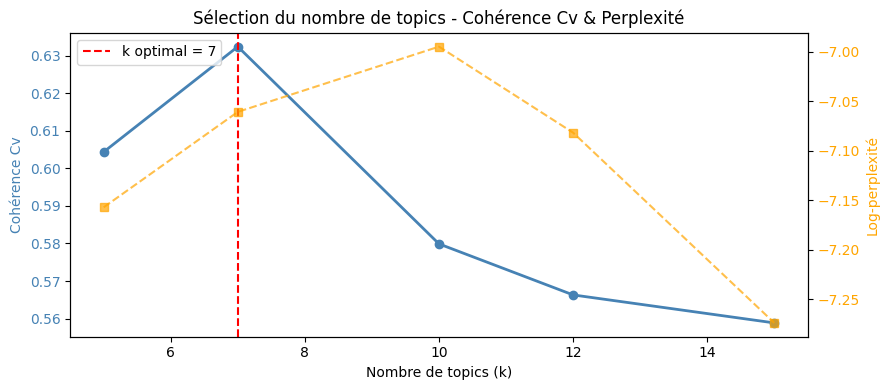

In [4]:
fig, ax1 = plt.subplots(figsize=(9, 4))

color_coh = "steelblue"
ax1.plot(K_RANGE, coherence_scores, "o-", color=color_coh, linewidth=2)
ax1.axvline(K_OPTIMAL, color="red", linestyle="--", label=f"k optimal = {K_OPTIMAL}")
ax1.set_xlabel("Nombre de topics (k)")
ax1.set_ylabel("Cohérence Cv", color=color_coh)
ax1.tick_params(axis="y", labelcolor=color_coh)
ax1.legend(loc="upper left")

ax2 = ax1.twinx()
ax2.plot(K_RANGE, perplexity_scores, "s--", color="orange", linewidth=1.5, alpha=0.7)
ax2.set_ylabel("Log-perplexité", color="orange")
ax2.tick_params(axis="y", labelcolor="orange")

ax1.set_title("Sélection du nombre de topics - Cohérence Cv & Perplexité")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_lda_coherence.png", dpi=150, bbox_inches="tight")
plt.show()

### A.3 Modèle LDA final

On entraîne le modèle LDA avec `k = K_OPTIMAL` et on augmente le nombre de `passes` pour la convergence.

In [5]:
lda_final = LdaModel(
    corpus=corpus_bow,
    id2word=dictionary,
    num_topics=K_OPTIMAL,
    passes=20,
    alpha="auto",
    eta="auto",
    random_state=42,
    eval_every=None
)

# Cohérence finale
cm_final = CoherenceModel(
    model=lda_final, texts=processed_texts,
    dictionary=dictionary, coherence="c_v"
)
print(f"Cohérence Cv du modèle final : {cm_final.get_coherence():.4f}")

/opt/python/lib/python3.13/multiprocessing/popen_fork.py:67: DeprecationWarning: This process (pid=11722) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/opt/python/lib/python3.13/multiprocessing/popen_fork.py:67: DeprecationWarning: This process (pid=11722) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/opt/python/lib/python3.13/multiprocessing/popen_fork.py:67: DeprecationWarning: This process (pid=11722) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/opt/python/lib/python3.13/multiprocessing/popen_fork.py:67: DeprecationWarning: This process (pid=11722) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/opt/python/lib/python3.13/multiprocessing/popen_fork.py:67: DeprecationWarning: This process (pid=11722) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()
/opt/pytho

Cohérence Cv du modèle final : 0.6324


### A.4 Interprétation qualitative des topics

On affiche les 15 mots les plus représentatifs de chaque topic et on leur attribue un **label interprétatif** - étape indispensable signalée par le prof (cours p.22 : *"Topic modelling is unsupervised and requires human interpretation"*).

> **À compléter manuellement** : les labels ci-dessous sont des propositions basées sur les mots-clés, à valider/modifier selon votre lecture.

In [6]:
# Affichage des tops mots par topic
print("=" * 70)
for topic_id in range(K_OPTIMAL):
    words = lda_final.show_topic(topic_id, topn=15)
    words_str = ", ".join([f"{w} ({p:.3f})" for w, p in words])
    print(f"\nTopic {topic_id:02d}:\n  {words_str}")
print("=" * 70)


Topic 00:
  falloir (0.006), contre (0.005), national (0.005), vie (0.005), vouloir (0.005), homme (0.004), défendre (0.004), communiste (0.004), grand (0.004), vote (0.004), progrès (0.004), ensemble (0.004), pouvoir (0.004), confiance (0.004), avenir (0.004)

Topic 01:
  national (0.010), défense (0.008), famille (0.008), priorité (0.008), suppression (0.007), enfant (0.007), création (0.007), contre (0.006), populaire (0.006), étranger (0.006), etat (0.006), lutte (0.006), immigration (0.006), entreprise (0.006), véritable (0.006)

Topic 02:
  travailleur (0.025), entreprise (0.015), payer (0.015), patron (0.015), maintenir (0.014), patronat (0.013), salaire (0.012), devoir (0.011), falloir (0.010), année (0.010), vendre (0.009), jeter (0.009), sacrifice (0.009), dire (0.009), rue (0.008)

Topic 03:
  immigration (0.016), immigré (0.016), vouloir (0.014), impôt (0.014), front (0.013), rétablir (0.012), voix (0.010), million (0.010), sauver (0.009), main (0.009), contre (0.009), ret

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# LABELS INTERPRÉTATIFS - À AJUSTER selon les résultats obtenus
# Les clés sont les numéros de topics (0 à K_OPTIMAL-1)
# ─────────────────────────────────────────────────────────────────────────────
# TOPIC_LABELS = {
#     0:  "Économie & emploi",
#     1:  "Sécurité & immigration",
#     2:  "Europe & international",
#     3:  "Social & santé",
#     4:  "Famille & éducation",
#     5:  "Environnement & agriculture",
#     6:  "Institutions & démocratie",
#     7:  "Logement & territoire",
#     8:  "Justice & libertés",
#     9:  "Culture & identité",
#     10: "Fiscalité & budget",
#     11: "Travail & syndicats",
#     # Ajouter ou modifier selon K_OPTIMAL
# }

# Compléter les labels manquants
for k in range(K_OPTIMAL):
    if k not in TOPIC_LABELS:
        TOPIC_LABELS[k] = f"Topic {k}"

print("Labels définis :")
for k, v in TOPIC_LABELS.items():
    print(f"  {k:2d} → {v}")

NameError: name 'TOPIC_LABELS' is not defined

### A.5 Distribution des topics par document

On récupère le vecteur de distribution thématique de chaque document (θ_d).

In [ ]:
# Inférence : distribution topics pour chaque doc
theta = np.zeros((len(corpus_bow), K_OPTIMAL))

for i, bow in enumerate(corpus_bow):
    doc_topics = lda_final.get_document_topics(bow, minimum_probability=0.0)
    for topic_id, prob in doc_topics:
        theta[i, topic_id] = prob

# Topic dominant par document
df["lda_topic_dominant"] = theta.argmax(axis=1)
df["lda_topic_label"] = df["lda_topic_dominant"].map(TOPIC_LABELS)

# Ajouter les colonnes de probabilités
for k in range(K_OPTIMAL):
    df[f"lda_topic_{k}"] = theta[:, k]

print("Distribution des topics dominants :")
print(df["lda_topic_label"].value_counts())

### A.6 Visualisation pyLDAvis

La visualisation interactive permet de vérifier la séparation des topics (bulles distinctes = bonne qualité) et d'explorer les mots discriminants via le paramètre λ.

In [ ]:
pyLDAvis.enable_notebook()
vis = pyLDAvis.gensim_models.prepare(
    lda_final, corpus_bow, dictionary,
    mds="mmds",  # plus stable que tsne sur grands corpus
    sort_topics=False
)
pyLDAvis.save_html(vis, str(FIGURES_DIR / "02_pyldavis.html"))
pyLDAvis.display(vis)

---
## PARTIE B - BERTopic

BERTopic est complémentaire au LDA : il exploite des embeddings contextuels (ici `paraphrase-multilingual-MiniLM-L12-v2`, adapté au français), ce qui permet de capturer des topics sémantiquement plus précis.

### B.1 Encodage des documents

> Les embeddings sont sauvegardés pour ne pas avoir à les recalculer à chaque exécution (calcul coûteux sur 5800 docs).

In [ ]:
EMBEDDINGS_PATH = PROCESSED_DIR / "embeddings_1993.npy"

docs_for_bert = df["clean_text"].tolist()

if EMBEDDINGS_PATH.exists():
    print("Chargement des embeddings depuis le cache...")
    embeddings = np.load(EMBEDDINGS_PATH)
else:
    print("Calcul des embeddings (peut prendre ~5 min sur CPU)...")
    embedding_model = SentenceTransformer(
        "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
    )
    embeddings = embedding_model.encode(
        docs_for_bert,
        batch_size=64,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True
    )
    np.save(EMBEDDINGS_PATH, embeddings)
    print(f"Embeddings sauvegardés → {EMBEDDINGS_PATH}")

print(f"Shape embeddings : {embeddings.shape}")

### B.2 Pipeline BERTopic

Les hyperparamètres clés :
- `UMAP` : réduit les embeddings à 5 dimensions (conserve la structure globale)
- `HDBSCAN` : clustering densité - `min_cluster_size` contrôle la granularité
- `CountVectorizer` : représentation c-TF-IDF des topics avec stopwords et bigrammes

In [ ]:
import spacy

try:
    nlp = spacy.load("fr_core_news_md")
except OSError:
    nlp = spacy.load("fr_core_news_sm")

STOPWORDS_BERT = list(nlp.Defaults.stop_words) + [
    "france", "français", "française", "francais", "francaise",
    "circonscription", "election", "elections", "legislative", "legislatives",
    "mars", "candidat", "candidats", "candidate", "suppléant", "suppléante",
    "votez", "voter", "vote", "madame", "monsieur", "mademoiselle",
    "notre", "nos", "votre", "vos",
    "politique", "pays", "po", "fonds", "cevipof", "cevipov",
    "cher", "chère", "compatriote", "concitoyen", "concitoyens"
]

umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

hdbscan_model = HDBSCAN(
    min_cluster_size=80,    # ~1,4% du corpus - ajuster si trop/peu de topics
    min_samples=10,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)

vectorizer_model = CountVectorizer(
    stop_words=STOPWORDS_BERT,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.80
)

topic_model = BERTopic(
    embedding_model=None,      # embeddings déjà calculés
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    calculate_probabilities=True,
    verbose=True
)

bert_topics, bert_probs = topic_model.fit_transform(docs_for_bert, embeddings)

topic_info = topic_model.get_topic_info()
n_topics_raw = len(topic_info[topic_info["Topic"] != -1])
n_outliers   = (topic_info[topic_info["Topic"] == -1]["Count"]).values
n_outliers   = n_outliers[0] if len(n_outliers) else 0
print(f"\nTopics trouvés : {n_topics_raw} | Outliers (-1) : {n_outliers}")

### B.3 Réduction du nombre de topics

Si BERTopic produit trop de topics granulaires, on les fusionne pour faciliter l'interprétation. On cible un nombre comparable à celui retenu pour le LDA.

In [ ]:
N_TOPICS_TARGET = K_OPTIMAL  # même cible que LDA pour la comparabilité

if n_topics_raw > N_TOPICS_TARGET:
    print(f"Réduction : {n_topics_raw} → {N_TOPICS_TARGET} topics")
    bert_topics_r, bert_probs_r = topic_model.reduce_topics(
        docs_for_bert, nr_topics=N_TOPICS_TARGET
    )
    topic_info = topic_model.get_topic_info()
else:
    bert_topics_r  = bert_topics
    bert_probs_r   = bert_probs
    print("Pas de réduction nécessaire.")

print("\nAperçu des topics BERTopic :")
print(topic_info[topic_info["Topic"] != -1][["Topic", "Count", "Name"]].to_string())

In [ ]:
# Affichage détaillé des mots par topic BERTopic
print("=" * 70)
for row in topic_info[topic_info["Topic"] != -1].itertuples():
    words = topic_model.get_topic(row.Topic)[:12]
    words_str = ", ".join([f"{w} ({s:.3f})" for w, s in words])
    print(f"\nBERTopic {row.Topic:02d} (n={row.Count}) :\n  {words_str}")
print("=" * 70)

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# LABELS BERTOPIC - À AJUSTER selon les résultats
# ─────────────────────────────────────────────────────────────────────────────
# BERT_TOPIC_LABELS = {
#     # Exemples - remplacer par les IDs réels et les labels appropriés
#     0:  "Économie & emploi",
#     1:  "Sécurité & immigration",
#     2:  "Europe & international",
#     3:  "Social & santé",
#     4:  "Famille & éducation",
#     5:  "Environnement & agriculture",
#     6:  "Institutions & démocratie",
#     7:  "Logement & territoire",
# }

# Intégrer au DataFrame
df["bert_topic"] = bert_topics_r
df["bert_topic_label"] = df["bert_topic"].map(
    lambda t: BERT_TOPIC_LABELS.get(t, f"Topic {t}" if t != -1 else "Outlier")
)

print("BERTopic - distribution (hors outliers) :")
print(df[df["bert_topic"] != -1]["bert_topic_label"].value_counts())

### B.4 Visualisations BERTopic interactives

In [ ]:
# Carte inter-topics (distance sémantique entre topics)
fig_map = topic_model.visualize_topics()
fig_map.write_html(str(FIGURES_DIR / "02_bert_intertopic_map.html"))
fig_map.show()

In [ ]:
# Barchart des top mots par topic
n_show = min(12, len(topic_info[topic_info["Topic"] != -1]))
fig_bar = topic_model.visualize_barchart(top_n_topics=n_show, n_words=8)
fig_bar.write_html(str(FIGURES_DIR / "02_bert_barchart.html"))
fig_bar.show()

---
## PARTIE C - Indicateurs de spécialisation partisane

C'est le cœur analytique de l'étape 2 : **est-ce que les partis se différencient d'abord par les thèmes abordés ?**

### C.1 Distribution moyenne des topics LDA par parti

In [ ]:
# Colonnes de probabilités LDA
lda_cols = [f"lda_topic_{k}" for k in range(K_OPTIMAL)]

# Distribution moyenne par parti (on exclut "Autre / indépendant" pour la clarté)
df_partis = df[df["parti_simplifie"] != "Autre / indépendant"].copy()

topic_by_party = (
    df_partis.groupby("parti_simplifie")[lda_cols]
    .mean()
)
topic_by_party.columns = [TOPIC_LABELS.get(int(c.split("_")[-1]), c) for c in lda_cols]

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    topic_by_party,
    cmap="YlOrRd",
    ax=ax,
    linewidths=0.3,
    annot=True,
    fmt=".2f",
    annot_kws={"fontsize": 7},
    cbar_kws={"label": "Poids moyen du topic"}
)
ax.set_title("Distribution moyenne des topics LDA par parti")
ax.set_xlabel("Topic")
ax.set_ylabel("Parti")
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_lda_topics_par_parti.png", dpi=150, bbox_inches="tight")
plt.show()

### C.2 Indice de spécialisation (log-ratio)

Pour chaque paire (parti, topic), on calcule un **log-ratio de spécialisation** :

$$\text{spec}_{p,k} = \log \frac{\bar{\theta}_{p,k}}{\bar{\theta}_{\cdot,k}}$$

où $\bar{\theta}_{p,k}$ est la probabilité moyenne du topic $k$ pour le parti $p$, et $\bar{\theta}_{\cdot,k}$ est la moyenne globale. Un score positif indique une **sur-représentation** du topic dans ce parti.

In [ ]:
global_mean = df_partis[lda_cols].mean()
global_mean.index = [TOPIC_LABELS.get(int(c.split("_")[-1]), c) for c in lda_cols]

# Log-ratio (éviter log(0) avec epsilon)
eps = 1e-6
log_ratio = np.log((topic_by_party + eps) / (global_mean + eps))

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    log_ratio,
    cmap="RdBu_r",
    center=0,
    ax=ax,
    linewidths=0.3,
    annot=True,
    fmt=".2f",
    annot_kws={"fontsize": 7},
    cbar_kws={"label": "Log-ratio de spécialisation"}
)
ax.set_title("Spécialisation thématique par parti (log-ratio vs moyenne globale)")
ax.set_xlabel("Topic")
ax.set_ylabel("Parti")
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_lda_specialisation.png", dpi=150, bbox_inches="tight")
plt.show()

### C.3 Topics les plus sur-représentés par parti

Lecture condensée : pour chaque parti, quel est son topic **signature** ?

In [ ]:
print("Topic le plus sur-représenté par parti (log-ratio maximal) :")
print("=" * 60)
for parti in log_ratio.index:
    top_topic = log_ratio.loc[parti].idxmax()
    score     = log_ratio.loc[parti].max()
    print(f"  {parti:<35} → {top_topic} (score={score:.2f})")

### C.4 Fréquence globale de chaque topic

In [ ]:
freq_topic = df["lda_topic_label"].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(10, 4))
freq_topic.sort_values().plot.barh(ax=ax, color="steelblue")
ax.set_xlabel("% des documents")
ax.set_title("Fréquence globale des topics (document dominant, LDA)")
for i, v in enumerate(freq_topic.sort_values()):
    ax.text(v + 0.1, i, f"{v:.1f}%", va="center", fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_lda_freq_topics.png", dpi=150, bbox_inches="tight")
plt.show()

### C.5 Comparaison LDA ↔ BERTopic par parti

On compare la distribution des topics dominants (BERTopic) entre partis pour valider la cohérence des deux approches.

In [ ]:
df_bert_partis = df[(df["parti_simplifie"] != "Autre / indépendant") & (df["bert_topic"] != -1)].copy()

bert_by_party = (
    df_bert_partis
    .groupby(["parti_simplifie", "bert_topic_label"])
    .size()
    .unstack(fill_value=0)
)
bert_by_party_pct = bert_by_party.div(bert_by_party.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    bert_by_party_pct,
    cmap="YlOrRd",
    ax=ax,
    linewidths=0.3,
    annot=True,
    fmt=".1f",
    annot_kws={"fontsize": 7},
    cbar_kws={"label": "% de documents du parti"}
)
ax.set_title("Distribution des topics BERTopic par parti (%)")
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_bert_topics_par_parti.png", dpi=150, bbox_inches="tight")
plt.show()

---
## PARTIE D - Sauvegarde et synthèse

In [ ]:
import os
os.makedirs(str(PROCESSED_DIR), exist_ok=True)

# Colonnes à sauvegarder
cols_save = (
    ["id", "titulaire-sexe", "parti_simplifie", "parti_principal",
     "lda_topic_dominant", "lda_topic_label", "bert_topic", "bert_topic_label"]
    + lda_cols
)
df[cols_save].to_csv(PROCESSED_DIR / "corpus_1993_topics.csv", index=False)
print("Sauvegardé → data/processed/corpus_1993_topics.csv")

# Sauvegarder le modèle BERTopic
topic_model.save(str(PROCESSED_DIR / "bertopic_model_1993"))
print("Sauvegardé → data/processed/bertopic_model_1993/")

# Sauvegarder le modèle LDA
lda_final.save(str(PROCESSED_DIR / "lda_model_1993"))
print("Sauvegardé → data/processed/lda_model_1993")

In [ ]:
print("\n" + "=" * 65)
print("SYNTHÈSE - Étape 2 : Identification des structures thématiques")
print("=" * 65)
print(f"  Méthode 1  : LDA (Gensim), k={K_OPTIMAL} topics (sélection par Cv)")
print(f"  Méthode 2  : BERTopic (paraphrase-multilingual-MiniLM-L12-v2)")
print(f"  Cohérence Cv finale LDA : {cm_final.get_coherence():.4f}")
n_bert_topics = len(topic_info[topic_info["Topic"] != -1])
print(f"  Topics BERTopic (après réduction) : {n_bert_topics}")
print(f"  Documents classifiés (BERTopic, hors outliers) : {(df['bert_topic'] != -1).sum()}")
print()
print("Prochaine étape → 03_semantic_framing.ipynb")
print("  Analyse du cadrage sémantique et émotionnel par topic et par parti")